# dar_problem_fixed_bo_embedding_compare best-so-far plots

This notebook loads the `dar_problem_fixed_bo_embedding_compare` trajectories and plots the best-so-far curves for each embedding method.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

candidate_paths = [
    Path.cwd() / "../outputs/dar_problem_fixed_bo_embedding_compare/embedding_trajectory.csv",
    Path.cwd() / "outputs/dar_problem_fixed_bo_embedding_compare/embedding_trajectory.csv",
    Path.cwd().parent / "outputs/dar_problem_fixed_bo_embedding_compare/embedding_trajectory.csv",
]

trajectory_path = next((path.resolve() for path in candidate_paths if path.exists()), None)
if trajectory_path is None:
    searched = "\n".join(str(path.resolve()) for path in candidate_paths)
    raise FileNotFoundError(f"Could not find embedding_trajectory.csv. Searched:\n{searched}")

trajectory_df = pd.read_csv(trajectory_path)
trajectory_df["iteration"] = trajectory_df["iteration"].astype(int)
trajectory_df["best_so_far"] = trajectory_df["best_so_far"].astype(float)

output_dir = trajectory_path.parent
trajectory_path

PosixPath('/home/sjtu/LLMBO/ChemBO-Agent/outputs/formal_run_80/dar_problem_fixed_bo_embedding_compare/embedding_trajectory.csv')

In [2]:
summary_df = (
    trajectory_df.groupby(["embedding_method", "iteration"], as_index=False)
    .agg(
        mean_best_so_far=("best_so_far", "mean"),
        std_best_so_far=("best_so_far", "std"),
        repeats=("run_id", "nunique"),
    )
)
summary_df["std_best_so_far"] = summary_df["std_best_so_far"].fillna(0.0)

final_order = (
    summary_df.sort_values("iteration")
    .groupby("embedding_method", as_index=False)
    .tail(1)
    .sort_values("mean_best_so_far", ascending=False)["embedding_method"]
    .tolist()
)

summary_df[summary_df["iteration"] == summary_df["iteration"].max()].sort_values(
    "mean_best_so_far", ascending=False
)[["embedding_method", "mean_best_so_far", "std_best_so_far", "repeats"]].reset_index(drop=True)

,embedding_method,mean_best_so_far,std_best_so_far,repeats
0,fingerprint_concat,89.636667,2.273881,3
1,molclr_concat,88.976667,1.986085,3
2,chemberta_concat,88.810000,0.942550,3
3,physicochemical_descriptors,88.216667,0.334863,3
4,one_hot,87.830000,0.000000,3


PosixPath('/home/sjtu/LLMBO/ChemBO-Agent/outputs/formal_run_80/dar_problem_fixed_bo_embedding_compare/formal_run_80_best_so_far.png')

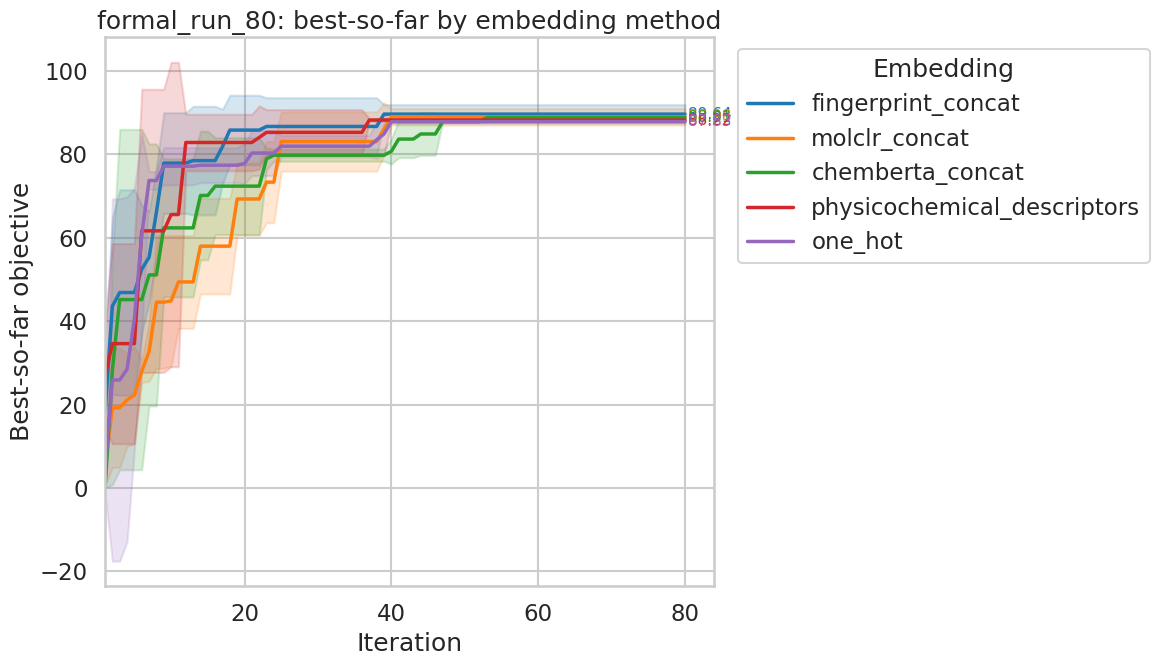

In [3]:
fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette("tab10", n_colors=len(final_order))

for color, method in zip(palette, final_order):
    method_df = summary_df[summary_df["embedding_method"] == method].sort_values("iteration")
    x = method_df["iteration"]
    y = method_df["mean_best_so_far"]
    y_std = method_df["std_best_so_far"]
    ax.plot(x, y, label=method, linewidth=2.5, color=color)
    ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.18)
    ax.text(x.iloc[-1] + 0.4, y.iloc[-1], f"{y.iloc[-1]:.2f}", color=color, va="center", fontsize=11)

ax.set_title("dar_problem_fixed_bo_embedding_compare: best-so-far by embedding method")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best-so-far objective")
ax.set_xlim(summary_df["iteration"].min(), summary_df["iteration"].max() + 4)
ax.legend(title="Embedding", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

figure_path = output_dir / "dar_problem_fixed_bo_embedding_compare_best_so_far.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
figure_path